In [8]:
import sys

custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
if custom_module_path not in sys.path:
    sys.path.append(custom_module_path)

import instruments_jax as inst
import copy
import numpy as np
import json


# Step 1.a): Reading in csv - extracting single diffs and sums and configurations

In [9]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"
wavelength_string = 720
obs_mode = "MBI"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)
print("Interleaved Values")
print("Length: ", len(interleaved_values))
print(interleaved_values)
print("Interleaved Stds")
print("Length: ", len(interleaved_stds))
print(interleaved_stds[0 : 10])
print("Configuration List")
print("Length: ", len(configuration_list))
print(configuration_list)

print(interleaved_stds[0])

Interleaved Values
Length:  320
[ 19443.    27359.5  -26523.5   29186.    10360.5   27538.5  -17840.5
  28326.   -10662.5   28418.5    3473.    27876.   -27267.5   29836.5
  21314.    27976.5  -27920.5   29951.5   23421.5   28214.   -12034.
  28774.     8556.    28492.5   10305.5   27996.5  -13423.    29077.
  21867.    27914.   -25387.5   29809.5   14391.5   28174.   -20535.5
  29352.5   20802.5   27697.   -27617.    29505.     9551.    28000.5
 -17167.5   28696.   -12391.5   28871.5    4892.5   28166.   -28211.
  30113.5   21892.5   28098.5  -27316.    29949.    22458.    28215.
 -10273.    28577.5    6538.5   28392.    11477.    27759.   -14727.5
  28943.     -867.5   29043.    -3647.    29198.    18165.5   28361.5
 -23641.    29681.5   22278.    28083.   -28827.    29929.     8984.
  28448.   -16566.    29038.   -13928.    29321.5    6282.    28442.5
 -28623.5   30393.    22020.    28267.5  -26182.    30032.    20955.
  28281.    -8140.    28472.     3993.5   28344.5  -16823.    29

In [10]:
%%timeit

import copy


copy.deepcopy(interleaved_values)

2.89 µs ± 163 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


# Step 1.b) - Make plot of existing values as double diffs and sums

# Step 2: Creating a system Mueller matrix object

In [11]:
# Loading in previous fit from vampires_calibration
filename = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/725-50_no_IMR_offset_iterate_on_any_improvement_with_dichroic_best_fit_old_fit_values.txt"
with open(filename, "r") as f:
    past_fit = json.load(f)
past_fit.pop("wollaston", None)
past_fit.setdefault("image_rotator", {})
past_fit["image_rotator"].pop("delta_theta", None)

print(past_fit)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"] 
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"] 
offset_derot = 0
delta_opts = past_fit["optics"]["phi"]
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"] 
rot_FLC = past_fit["flc"]["delta_theta"]
em_gain = 1.2 # from EM gain measurements

# Based on values in Six_And_Eleven_Parameter_Model_Best_MCMC_and_Scipy_Fits Google Sheets - having zeros for angles that're too large
# theta_pol = 0
# delta_HWP = 0.451  # Add your actual delta_HWP value
# offset_HWP = -2.642  # Add your actual offset_HWP value
# delta_derot = 0.32  # Add your actual delta_derot value
# offset_derot = 0  # Add your actual offset_derot value
# delta_opts = 0  # Add your actual delta_opts value
# epsilon_opts = 0  # Add your actual epsilon_opts value
# rot_opts = 0  # Add your actual rot_opts value
# delta_FLC = 0.5  # Add your actual delta_FLC value
# rot_FLC = 0  # Add your actual rot_FLC value
# em_gain = 1.2  # Add your actual em_gain value

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary
system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta" : 0},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": delta_opts, "epsilon": epsilon_opts, "theta": rot_opts},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_derot, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        }
    }
}

{'dichroic': {'phi': -0.03540723843438347, 'epsilon': 0.3671420783517608, 'theta': -44.57669246708937}, 'flc': {'phi': 3.219372252852101, 'delta_theta': 4.999999997312573}, 'optics': {'phi': 0.3379980715556904, 'epsilon': 0.003090266607428392, 'theta': -48.51773887044277}, 'image_rotator': {'phi': 2.7531810131588093}, 'hwp': {'phi': 2.997151278890313, 'delta_theta': 1.3880794728687822}, 'lp': {'theta': 4.532892477428982}}


In [12]:
# Converting system dictionary into system Mueller Matrix object

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())

[[0.57314606 0.56598637 0.0903097  0.        ]
 [0.57314606 0.56598637 0.0903097  0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]]


# Step 4: Creating a dictionary of p0 starting guesses

{'dichroic': {'phi': -0.03540723843438347, 'epsilon': 0.3671420783517608, 'theta': -44.57669246708937}, 'flc': {'phi': 3.219372252852101, 'delta_theta': 4.999999997312573}, 'optics': {'phi': 0.3379980715556904, 'epsilon': 0.003090266607428392, 'theta': -48.51773887044277}, 'image_rotator': {'phi': 2.7531810131588093}, 'hwp': {'phi': 2.997151278890313, 'delta_theta': 1.3880794728687822}, 'lp': {'theta': 4.532892477428982}}
logl value: 6423.291623812043


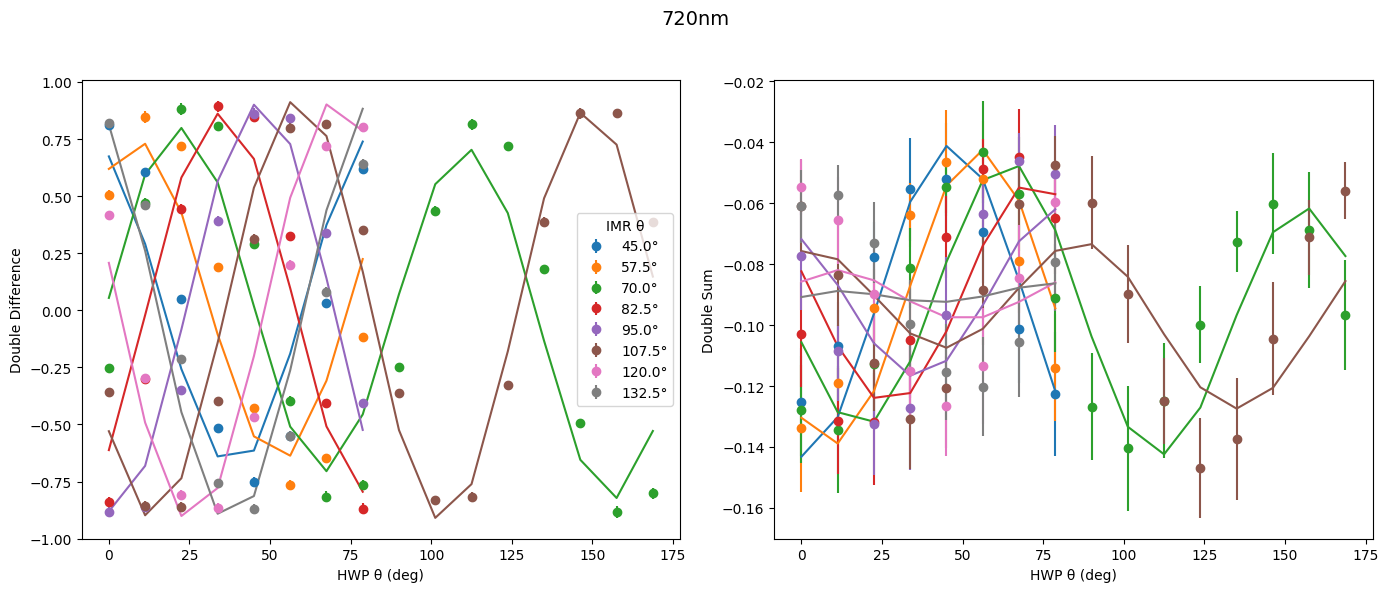

In [13]:
# Fitting all non-EM-gain parameters
p0 = copy.deepcopy(past_fit)
p0.pop("wollaston", None)

print(p0)

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 5: Running minimize_system_Mueller_matrix iteratively

Before p0: {'dichroic': {'phi': -0.03540723843438347, 'epsilon': 0.3671420783517608, 'theta': -44.57669246708937}, 'flc': {'phi': 3.219372252852101, 'delta_theta': 4.999999997312573}, 'optics': {'phi': 0.3379980715556904, 'epsilon': 0.003090266607428392, 'theta': -48.51773887044277}, 'image_rotator': {'phi': 2.7531810131588093}, 'hwp': {'phi': 2.997151278890313, 'delta_theta': 1.3880794728687822}, 'lp': {'theta': 4.532892477428982}}
Iteration #: 1
logl_value: 71.15666989479368
Best Fit Parameters: [-1.40341971e-02  2.67665003e-01 -4.49072058e+01  3.24762662e+00
 -5.43689993e-01  1.00540385e-01  3.73039018e-03 -7.69077196e+01
  2.62083268e+00  2.98715050e+00  2.02966438e+00  4.20893540e+00]


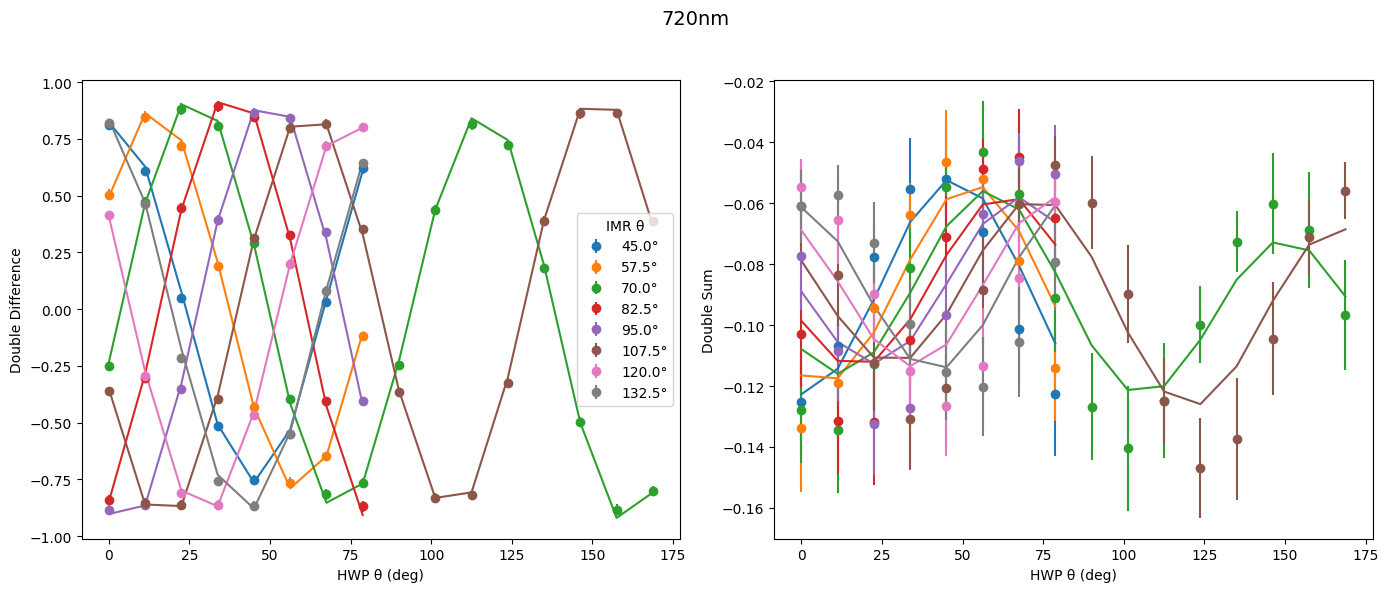

After p0: {'dichroic': {'phi': -0.014034197091248111, 'epsilon': 0.26766500300107365, 'theta': -44.90720576894054}, 'flc': {'phi': 3.2476266239287312, 'delta_theta': -0.5436899927245142}, 'optics': {'phi': 0.10054038538356147, 'epsilon': 0.003730390184259611, 'theta': -76.90771959284882}, 'image_rotator': {'phi': 2.6208326813321907}, 'hwp': {'phi': 2.987150500660672, 'delta_theta': 2.0296643766395164}, 'lp': {'theta': 4.208935395989865}}
Before p0: {'dichroic': {'phi': -0.014034197091248111, 'epsilon': 0.26766500300107365, 'theta': -44.90720576894054}, 'flc': {'phi': 3.2476266239287312, 'delta_theta': -0.5436899927245142}, 'optics': {'phi': 0.10054038538356147, 'epsilon': 0.003730390184259611, 'theta': -76.90771959284882}, 'image_rotator': {'phi': 2.6208326813321907}, 'hwp': {'phi': 2.987150500660672, 'delta_theta': 2.0296643766395164}, 'lp': {'theta': 4.208935395989865}}
Iteration #: 2
logl_value: 19.27520745505577
Best Fit Parameters: [-4.24857225e-03  2.93594378e-01 -4.47677462e+01 

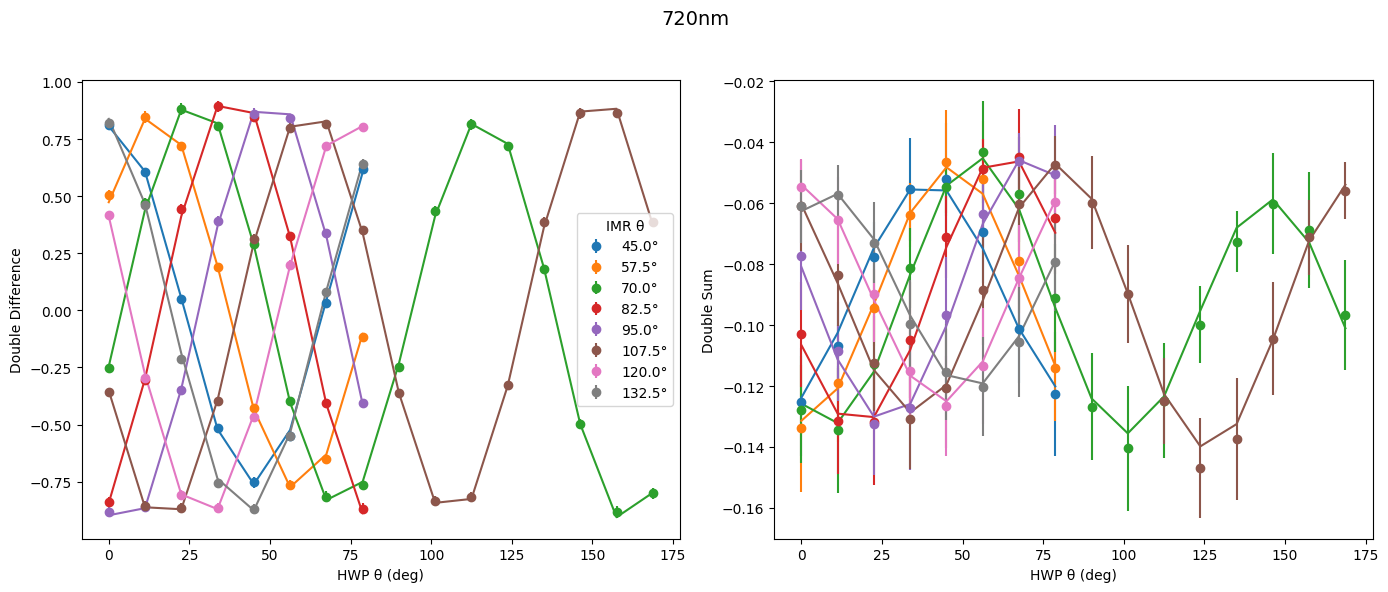

After p0: {'dichroic': {'phi': -0.004248572252837545, 'epsilon': 0.2935943784035395, 'theta': -44.76774623713186}, 'flc': {'phi': 3.2608950427269363, 'delta_theta': 0.46062749007658965}, 'optics': {'phi': 0.2748272477875622, 'epsilon': 0.006006960674223429, 'theta': -4.58142690675162}, 'image_rotator': {'phi': 2.6244805728916667}, 'hwp': {'phi': 2.991359308693431, 'delta_theta': 1.1820600552111076}, 'lp': {'theta': 4.977776480880891}}
Before p0: {'dichroic': {'phi': -0.004248572252837545, 'epsilon': 0.2935943784035395, 'theta': -44.76774623713186}, 'flc': {'phi': 3.2608950427269363, 'delta_theta': 0.46062749007658965}, 'optics': {'phi': 0.2748272477875622, 'epsilon': 0.006006960674223429, 'theta': -4.58142690675162}, 'image_rotator': {'phi': 2.6244805728916667}, 'hwp': {'phi': 2.991359308693431, 'delta_theta': 1.1820600552111076}, 'lp': {'theta': 4.977776480880891}}
Iteration #: 3
logl_value: 15.92075822183831
Best Fit Parameters: [-4.26914209e-02  2.96570958e-01 -4.47381485e+01  3.192

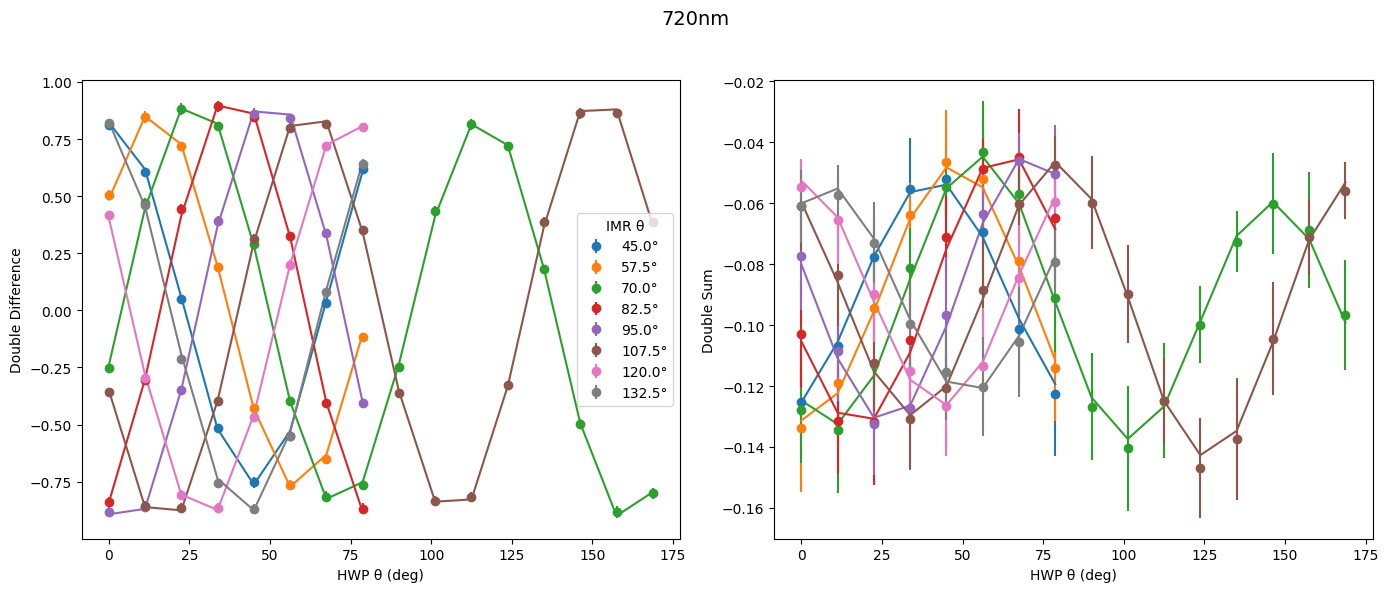

After p0: {'dichroic': {'phi': -0.04269142088395511, 'epsilon': 0.29657095769087793, 'theta': -44.73814852895987}, 'flc': {'phi': 3.1929624096293967, 'delta_theta': 1.1369187112422656}, 'optics': {'phi': 0.21398613847353198, 'epsilon': 0.004545059153906312, 'theta': 1.1046908554628292}, 'image_rotator': {'phi': 2.626102584935248}, 'hwp': {'phi': 2.9885728176457675, 'delta_theta': -2.1044444806436537}, 'lp': {'theta': -0.22936111013091243}}
Before p0: {'dichroic': {'phi': -0.04269142088395511, 'epsilon': 0.29657095769087793, 'theta': -44.73814852895987}, 'flc': {'phi': 3.1929624096293967, 'delta_theta': 1.1369187112422656}, 'optics': {'phi': 0.21398613847353198, 'epsilon': 0.004545059153906312, 'theta': 1.1046908554628292}, 'image_rotator': {'phi': 2.626102584935248}, 'hwp': {'phi': 2.9885728176457675, 'delta_theta': -2.1044444806436537}, 'lp': {'theta': -0.22936111013091243}}
Iteration #: 4
logl_value: 15.917943186737249
Best Fit Parameters: [-4.47813882e-02  2.96404161e-01 -4.47387065

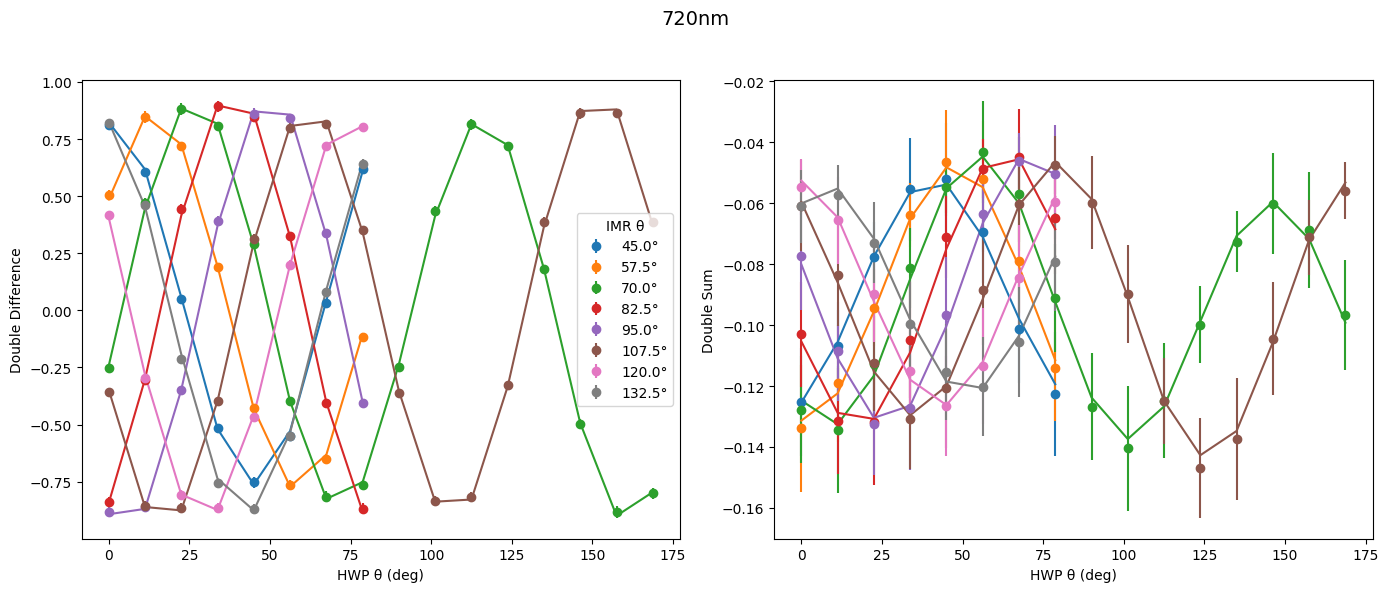

After p0: {'dichroic': {'phi': -0.04478138819482756, 'epsilon': 0.2964041614554641, 'theta': -44.73870645830628}, 'flc': {'phi': 3.189030611576494, 'delta_theta': 1.131994006695645}, 'optics': {'phi': 0.21432600173798677, 'epsilon': 0.0045345554307480804, 'theta': 1.3183065250040849}, 'image_rotator': {'phi': 2.6261803355213225}, 'hwp': {'phi': 2.988686048111596, 'delta_theta': -2.033579073642004}, 'lp': {'theta': -0.10410036489111524}}
Before p0: {'dichroic': {'phi': -0.04478138819482756, 'epsilon': 0.2964041614554641, 'theta': -44.73870645830628}, 'flc': {'phi': 3.189030611576494, 'delta_theta': 1.131994006695645}, 'optics': {'phi': 0.21432600173798677, 'epsilon': 0.0045345554307480804, 'theta': 1.3183065250040849}, 'image_rotator': {'phi': 2.6261803355213225}, 'hwp': {'phi': 2.988686048111596, 'delta_theta': -2.033579073642004}, 'lp': {'theta': -0.10410036489111524}}
Iteration #: 5
logl_value: 15.917943185374615
Best Fit Parameters: [-4.47818451e-02  2.96404033e-01 -4.47387050e+01  

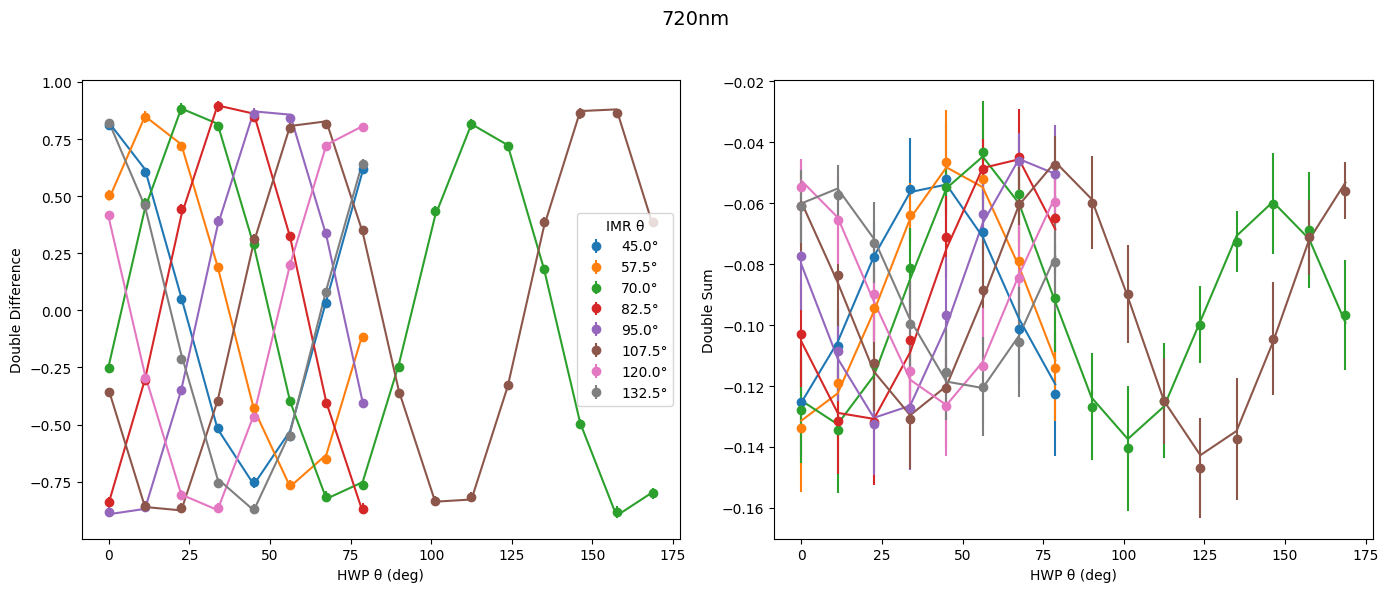

After p0: {'dichroic': {'phi': -0.04478184506569202, 'epsilon': 0.29640403264022375, 'theta': -44.73870495369522}, 'flc': {'phi': 3.189029900699927, 'delta_theta': 1.1319902648632847}, 'optics': {'phi': 0.2143254371696785, 'epsilon': 0.004534592658655261, 'theta': 1.3183124340877548}, 'image_rotator': {'phi': 2.6261802949603767}, 'hwp': {'phi': 2.9886860256424006, 'delta_theta': -2.0335827474561015}, 'lp': {'theta': -0.10411954131157666}}
Before p0: {'dichroic': {'phi': -0.04478184506569202, 'epsilon': 0.29640403264022375, 'theta': -44.73870495369522}, 'flc': {'phi': 3.189029900699927, 'delta_theta': 1.1319902648632847}, 'optics': {'phi': 0.2143254371696785, 'epsilon': 0.004534592658655261, 'theta': 1.3183124340877548}, 'image_rotator': {'phi': 2.6261802949603767}, 'hwp': {'phi': 2.9886860256424006, 'delta_theta': -2.0335827474561015}, 'lp': {'theta': -0.10411954131157666}}
Iteration #: 6
logl_value: 15.917943185374615
Best Fit Parameters: [-4.47818451e-02  2.96404033e-01 -4.47387050e+

In [14]:
# Unpolarized light for s_in as there is LP in the system already
s_in = np.array([1, 0, 0, 0])
bounds_dict = {
    "dichroic": {
        "phi": (-2 * np.pi, 2 * np.pi),
        "epsilon": (0, 1),
        "theta": (-90, 90)
    },
    "flc": {
        "phi": (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),
        "delta_theta": (-5, 5)
    },
    "optics": {
        "phi": (-np.pi, np.pi),
        "epsilon": (0, 1),
        "theta": (-90, 90)
    },
    "image_rotator": {
        "phi": (-2 * np.pi, 2 * np.pi),
    },
    "hwp": {
        "phi": (
             (-2 * np.pi, 2 * np.pi)
        ),
        "delta_theta": (-5, 5)
    },
    "lp": {
        "theta": (-5, 5)
    }
}

# Now flatten the bounds in the same order as p0_keywords
p0_values, p0_keywords = inst.parse_configuration(p0)
for (comp, param), val in zip(p0_keywords, p0_values):
    lower, upper = bounds_dict[comp][param]
    if not (lower <= val <= upper):
        print(f"{comp}.{param} = {val} is outside bounds {lower} to {upper}")
bounds = [bounds_dict[comp][param] for comp, param in p0_keywords]

# Counters for iterative fitting
iteration = 1
previous_logl_value = np.inf
new_logl_value = None
best_result = None

while True:
    print("Before p0: " + str(p0))
    result, new_logl_value = inst.minimize_system_mueller_matrix(p0, system_mm, 
        interleaved_values, interleaved_stds, configuration_list, s_in = s_in,
        process_dataset = inst.process_dataset, 
        process_errors = inst.process_errors, 
        process_model = inst.process_model, bounds = bounds)
    new_logl_value = float(new_logl_value)
    
    # Print statements
    print("Iteration #: " + str(iteration))
    print("logl_value: " + str(new_logl_value))
    print("Best Fit Parameters: " + str(result.x))

    if new_logl_value >= previous_logl_value:
        print("Stopping: logl did not improve over the previous iteration.")
        if best_result is not None:
            result = best_result
        break

    previous_logl_value = new_logl_value
    best_result = result

    # Making a plot
    updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
    model = inst.model(result.x, p0_keywords, updated_system_mm, configuration_list, 
    process_model = inst.process_model)

    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
        configuration_list, wavelength = wavelength_string)

    # Updating p0 for next time
    inst.update_p0(p0, result.x)
    print("After p0: " + str(p0))

    filename = f"/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/{wavelength_string}_no_IMR_offset_fixed_EM_gain_no_retardance_constraints_iterate_on_any_improvement_with_dichroic_best_fit_old_fit_values.txt"
    with open(filename, 'w') as f:
        json.dump(p0, f, indent=4)

    iteration += 1

# Step 6: Plot model with best fit

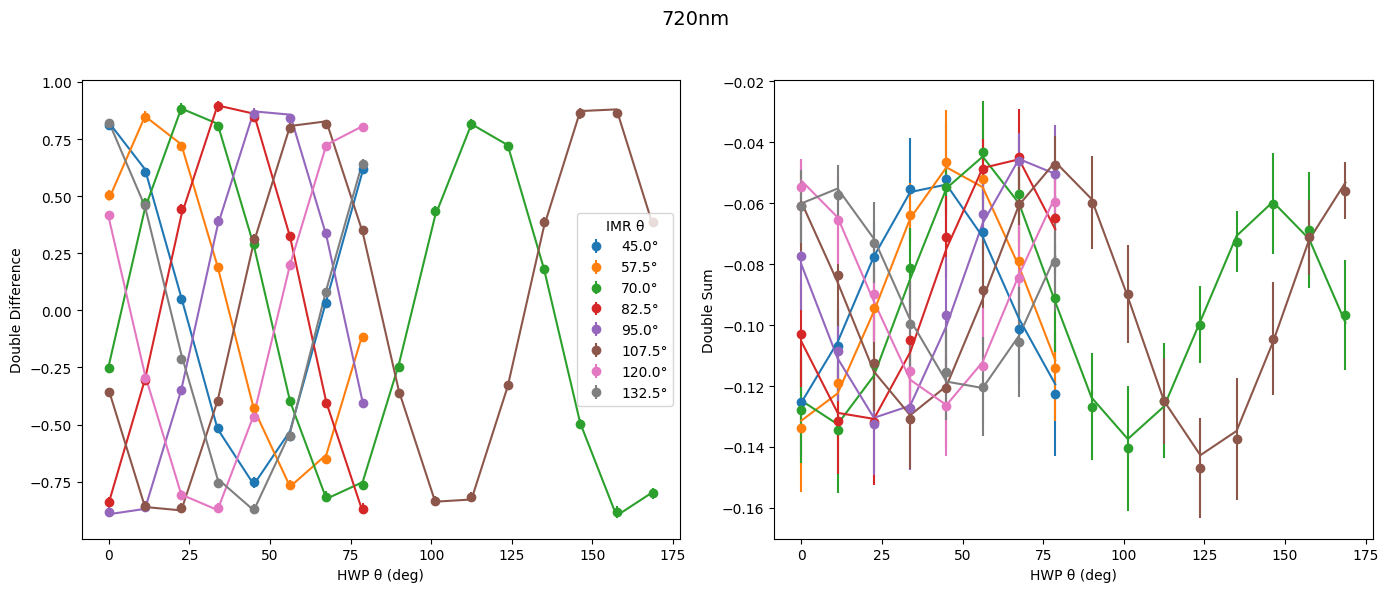

In [15]:
# Generate model with p0 keywords but scipy minimized results
# print(result.x)
# print(p0_keywords)

# Manually adjusting for a good fit
dichroic_phi = 0 # (waves)
dichroic_theta = 0 # (degrees)
# result.x = [2 * np.pi * dichroic_phi, dichroic_theta]

updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
model = inst.model(result.x, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)